In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install cartopy airportsdata
import networkx as nx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import airportsdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.8/934.8 kB 40.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/ulfadwyh002/Data-Skripsi-Airport-Dataset/main/Data_1.xlsx"
data = pd.read_excel(url)

data.head(20)


,IATA_Origin,IATA_Destination,Airline_Code
0,BPN,TRK,Super Air Jet
1,BPN,TRK,Citilink
2,BPN,PNK,Batik Air
3,BPN,PNK,Super Air Jet
4,BPN,PNK,Garuda Indonesia
5,BPN,PNK,Citilink
6,BPN,PNK,Lion Air
7,BPN,BDJ,Wings Air
8,BPN,BTJ,Garuda Indonesia
9,BPN,BTJ,Super Air Jet


In [ ]:
# Menampilkan jumlah baris
print("Jumlah raw data:", len(data))
# Menampilkan data
data

Jumlah raw data: 1974


,IATA_Origin,IATA_Destination,Airline_Code
0,BPN,TRK,Super Air Jet
1,BPN,TRK,Citilink
2,BPN,PNK,Batik Air
3,BPN,PNK,Super Air Jet
4,BPN,PNK,Garuda Indonesia
...,...,...,...
1969,DTB,BTH,Super Air Jet
1970,DTB,LOP,Super Air Jet
1971,DTB,PNK,Super Air Jet
1972,DTB,BDJ,Super Air Jet


In [ ]:
# Bersihkan spasi di awal/akhir teks pada kolom IATA
data['IATA_Origin'] = data['IATA_Origin'].str.strip()
data['IATA_Destination'] = data['IATA_Destination'].str.strip()

In [ ]:
origin_set = set(data['IATA_Origin'].dropna().unique())
dest_set   = set(data['IATA_Destination'].dropna().unique())


In [ ]:
# Melihat daftar IATA Origin unik
unique_origins = data["IATA_Origin"].unique()
print(unique_origins)

#Total Daftar IATA_origin
total_origin = data["IATA_Origin"].nunique()
print(f"Total IATA_Origin unik = {total_origin}")

['BPN' 'AAP' 'BTJ' 'KNO' 'PDG' 'PKU' 'BTH' 'CGK' 'KJT' 'YIA' 'SUB' 'DPS'
 'LOP' 'UPG' 'MDC' 'DJJ' 'LBJ' 'PLM' 'TJQ' 'SRG' 'BDJ' 'PNK' 'TNJ' 'TKG'
 'SOC' 'BWX' 'TRK' 'KOE' 'AMQ' 'BIK' 'SOQ' 'DTB']
Total IATA_Origin unik = 32


In [ ]:
# Melihat daftar IATA Origin unik
unique_destination = data["IATA_Destination"].unique()
print(unique_destination)

#Total Daftar IATA_origin
total_destination = data["IATA_Destination"].nunique()
print(f"Total IATA_Destination unik = {total_destination}")

['TRK' 'PNK' 'BDJ' 'BTJ' 'KNO' 'PDG' 'PKU' 'BTH' 'CGK' 'HLP' 'YIA' 'SUB'
 'DPS' 'LOP' 'UPG' 'MDC' 'DJJ' 'PLM' 'TJQ' 'SRG' 'TKG' 'SOC' 'BWX' 'KOE'
 'MKQ' 'PLW' 'SOQ' 'LBJ' 'BPN' 'AMQ' 'AAP' 'BIK' 'TNJ']
Total IATA_Destination unik = 33


## Cek bandara yang tujuan-only

In [ ]:
destination_only = sorted(dest_set - origin_set)

print("Bandara destination-only:")
print(destination_only)
print("Jumlah:", len(destination_only))


Bandara destination-only:
['HLP', 'MKQ', 'PLW']
Jumlah: 3


In [ ]:
data[data['IATA_Destination'].isin(destination_only)][
    ['IATA_Origin', 'IATA_Destination', 'Airline_Code']
].head(10)

,IATA_Origin,IATA_Destination,Airline_Code
37,BPN,HLP,CItilink
38,BPN,HLP,Super Air Jet
39,BPN,HLP,Pelita Air Service
40,BPN,HLP,Batik Air
41,BPN,HLP,Garuda Indonesia
89,BPN,MKQ,Lion Air
90,BPN,PLW,Wings Air
91,BPN,PLW,Lion Air
92,BPN,PLW,Garuda Indonesia
106,AAP,HLP,Citilink


In [ ]:
origin_only = sorted(origin_set-dest_set)

print("Bandara origin-only:")
print(origin_only)
print("Jumlah:", len(origin_only))

Bandara origin-only:
['DTB', 'KJT']
Jumlah: 2


In [ ]:
data[data['IATA_Origin'].isin(origin_only)][
    ['IATA_Origin', 'IATA_Destination', 'Airline_Code']
].head(10)

,IATA_Origin,IATA_Destination,Airline_Code
686,KJT,PDG,Scoot
687,KJT,MDC,Scoot
1957,DTB,CGK,AirAsia
1958,DTB,CGK,Super Air Jet
1959,DTB,CGK,Citilink
1960,DTB,DPS,Super Air Jet
1961,DTB,DPS,AirAsia
1962,DTB,DPS,Citilink
1963,DTB,UPG,Super Air Jet
1964,DTB,BPN,Super Air Jet


## Total simpul

In [ ]:
# Gabungkan dua kolom dan ambil nilai uniknya
unique_airports = pd.unique(data[['IATA_Origin', 'IATA_Destination']].values.ravel())

# Konversi ke list (opsional)
unique_airports = list(unique_airports)

# Tampilkan jumlah dan daftar unik bandara
print(f"Jumlah bandara unik: {len(unique_airports)}")
print(unique_airports)

Jumlah bandara unik: 35
['BPN', 'TRK', 'PNK', 'BDJ', 'BTJ', 'KNO', 'PDG', 'PKU', 'BTH', 'CGK', 'HLP', 'YIA', 'SUB', 'DPS', 'LOP', 'UPG', 'MDC', 'DJJ', 'PLM', 'TJQ', 'SRG', 'TKG', 'SOC', 'BWX', 'KOE', 'MKQ', 'PLW', 'SOQ', 'AAP', 'LBJ', 'AMQ', 'BIK', 'TNJ', 'KJT', 'DTB']


## Airline
distribusi maskapai

In [ ]:
# Membuat DataFrame dari daftar unik
unique_airline_df = pd.DataFrame(data["Airline_Code"].value_counts().reset_index())
unique_airline_df.columns = ["Airline_Code", "Count"]
display(unique_airline_df)

# Total Airline unik
total_airline = data["Airline_Code"].nunique()
print(f"Total IATA_Airline unik = {total_airline}")


,Airline_Code,Count
0,Garuda Indonesia,445
1,Lion Air,401
2,Batik Air,297
3,Super Air Jet,275
4,Citilink,244
5,Pelita Air Service,88
6,AirAsia,75
7,Sriwijaya Air,35
8,Scoot,21
9,Sriwijya Air,12


Total IATA_Airline unik = 31


In [ ]:
mapping_to_code = {

    "Garuda Indonesia": "GA",
    "GarudaIndonesia": "GA",
    "Lion Air": "JT",
    "Lion Ar": "JT",
    "Batik Air": "ID",
    "Super Air Jet": "IU",
    "Wings Air": "IW",
    "WingsAir": "IW",
    "Sriwijaya Air": "SJ",
    "Sriwijya Air": "SJ",
    "NAM Air": "IN",
    "Citilink": "QG",
    "Citiliink": "QG",
    "Citillink": "QG",
    "CItilink": "QG",
    "AirAsia": "QZ",
    "Air Asia": "QZ",
    "Indonesia AirAsia": "QZ",
    "Pelita Air Service": "IP",
    "Scoot": "TR",
    "SCoot": "TR",
    "Singapore Airlines": "SQ",
    "Singapore Airliness": "SQ",
    "Malaysia Airlines": "MH",
    "TransNusa": "8B"
}

In [ ]:
# Bersihkan spasi dan seragamkan huruf
data["Airline_Code"] = data["Airline_Code"].str.strip()

# Terapkan mapping ke kode IATA
data["Airline_Code"] = data["Airline_Code"].replace(mapping_to_code)

# Cek distribusi ulang dari Airline_Code
print(data["Airline_Code"].value_counts())


Airline_Code
GA    452
JT    404
ID    297
IU    277
QG    255
IP     89
QZ     78
SJ     47
TR     23
IN     11
SQ     11
IW     10
MH     10
8B     10
Name: count, dtype: int64


In [ ]:
# Menampilkan data
data

,IATA_Origin,IATA_Destination,Airline_Code
0,BPN,TRK,IU
1,BPN,TRK,QG
2,BPN,PNK,ID
3,BPN,PNK,IU
4,BPN,PNK,GA
...,...,...,...
1969,DTB,BTH,IU
1970,DTB,LOP,IU
1971,DTB,PNK,IU
1972,DTB,BDJ,IU


# Hapus duplikat data

In [ ]:
dup_mask = data.duplicated(
    subset=['IATA_Origin', 'IATA_Destination', 'Airline_Code'],
    keep=False
)

In [ ]:
df_duplikat = data[dup_mask].sort_values(
    by=['IATA_Origin', 'IATA_Destination', 'Airline_Code']
)

df_duplikat

,IATA_Origin,IATA_Destination,Airline_Code
26,BPN,BTH,JT
30,BPN,BTH,JT
10,BPN,KNO,JT
15,BPN,KNO,JT
0,BPN,TRK,IU
...,...,...,...
1215,MDC,SRG,JT
327,PDG,UPG,GA
333,PDG,UPG,GA
384,PKU,SUB,ID


In [ ]:
data2 = data.drop_duplicates(
    subset=['IATA_Origin', 'IATA_Destination', 'Airline_Code'],
    keep='first'
)

In [ ]:
data2

,IATA_Origin,IATA_Destination,Airline_Code
0,BPN,TRK,IU
1,BPN,TRK,QG
2,BPN,PNK,ID
3,BPN,PNK,IU
4,BPN,PNK,GA
...,...,...,...
1969,DTB,BTH,IU
1970,DTB,LOP,IU
1971,DTB,PNK,IU
1972,DTB,BDJ,IU


# Melengkapi data

In [ ]:

airport_master = {
    "BTJ": {
        "Airport_Name": "Bandar Udara Sultan Iskandar Muda",
        "City": "Kabupaten Aceh Besar",
        "Province": "Aceh"
    },
    "KNO": {
        "Airport_Name": "Bandar Udara Kualanamu",
        "City": "Kabupaten Deli Serdang",
        "Province": "Sumatra Utara"
    },
    "PDG": {
        "Airport_Name": "Bandar Udara Minangkabau",
        "City": "Kabupaten Padang Pariaman",
        "Province": "Sumatra Barat"
    },
    "PKU": {
        "Airport_Name": "Bandar Udara Sultan Syarif Kasim II",
        "City": "Kota Pekanbaru",
        "Province": "Riau"
    },
    "BTH": {
        "Airport_Name": "Bandar Udara Hang Nadim",
        "City": "Kota Batam",
        "Province": "Kepulauan Riau"
    },
    "CGK": {
        "Airport_Name": "Bandar Udara Soekarno Hatta",
        "City": "Kota Tangerang",
        "Province": "Banten"
    },
    "HLP": {
        "Airport_Name": "Bandar Udara Halim Perdanakusuma",
        "City": "Kota Jakarta Timur",
        "Province": "DKI Jakarta"
    },
    "KJT": {
        "Airport_Name": "Bandar Udara Kertajati",
        "City": "Kabupaten Majalengka",
        "Province": "Jawa Barat"
    },
    "YIA": {
        "Airport_Name": "Bandar Udara Kulon Progo",
        "City": "Kabupaten Kulon Progo",
        "Province": "DI Yogyakarta"
    },
    "SUB": {
        "Airport_Name": "Bandar Udara Juanda",
        "City": "Kabupaten Sidoarjo",
        "Province": "Jawa Timur"
    },
    "DPS": {
        "Airport_Name": "Bandar Udara I Gusti Ngurah Rai",
        "City": "Kabupaten Badung",
        "Province": "Bali"
    },
    "LOP": {
        "Airport_Name": "Bandar Udara Zainuddin Abdul Madjid",
        "City": "Kabupaten Lombok Tengah",
        "Province": "Nusa Tenggara Barat"
    },
    "BPN": {
        "Airport_Name": "Bandar Udara Sultan Aji Muhammad Sulaiman",
        "City": "Kota Balikpapan",
        "Province": "Kalimantan Timur"
    },
    "UPG": {
        "Airport_Name": "Bandar Udara Sultan Hasanuddin",
        "City": "Kabupaten Maros",
        "Province": "Sulawesi Selatan"
    },
    "MDC": {
        "Airport_Name": "Bandar Udara Sam Ratulangi",
        "City": "Kota Manado",
        "Province": "Sulawesi Utara"
    },
    "DJJ": {
        "Airport_Name": "Bandar Udara Sentani",
        "City": "Kabupaten Jayapura",
        "Province": "Papua"
    },
    "LBJ": {
        "Airport_Name": "Bandar Udara Komodo",
        "City": "Kabupaten Manggarai Barat",
        "Province": "Nusa Tenggara Timur"
    },
    "PLM": {
        "Airport_Name": "Bandar Udara S.M. Badaruddin II",
        "City": "Kota Palembang",
        "Province": "Sumatera Selatan"
    },
    "TJQ": {
        "Airport_Name": "Bandar Udara H.A.S. Hanandjoeddin",
        "City": "Kabupaten Belitung",
        "Province": "Kepulauan Bangka Belitung"
    },
    "SRG": {
        "Airport_Name": "Bandar Udara Jenderal Ahmad Yani",
        "City": "Kota Semarang",
        "Province": "Jawa Tengah"
    },
    "BDJ": {
        "Airport_Name": "Bandar Udara Syamsudin Noor",
        "City": "Kota Banjarbaru",
        "Province": "Kalimantan Selatan"
    },
    "PNK": {
        "Airport_Name": "Bandar Udara Supadio",
        "City": "Kota Pontianak",
        "Province": "Kalimantan Barat"
    },
    "TNJ": {
        "Airport_Name": "Bandar Udara Raja Haji Fisabilillah",
        "City": "Kota Tanjung Pinang",
        "Province": "Kepulauan Riau"
    },
    "TKG": {
        "Airport_Name": "Bandar Udara Radin Inten II",
        "City": "Kabupaten Lampung Selatan",
        "Province": "Lampung"
    },
    "SOC": {
        "Airport_Name": "Bandar Udara Adi Soemarmo",
        "City": "Kabupaten Boyolali",
        "Province": "Jawa Tengah"
    },
    "BWX": {
        "Airport_Name": "Bandar Udara Banyuwangi",
        "City": "Kabupaten Banyuwangi",
        "Province": "Jawa Timur"
    },
    "TRK": {
        "Airport_Name": "Bandar Udara Juwata",
        "City": "Kota Tarakan",
        "Province": "Kalimantan Utara"
    },
    "KOE": {
        "Airport_Name": "Bandar Udara El Tari",
        "City": "Kota Kupang",
        "Province": "Nusa Tenggara Timur"
    },
    "AMQ": {
        "Airport_Name": "Bandar Udara Pattimura",
        "City": "Kota Ambon",
        "Province": "Maluku"
    },
    "BIK": {
        "Airport_Name": "Bandar Udara Frans Kaisiepo",
        "City": "Kabupaten Biak Numfor",
        "Province": "Papua"
    },
    "MKQ": {
        "Airport_Name": "Bandar Udara Mopah",
        "City": "Kabupaten Merauke",
        "Province": "Papua Selatan"
    },
    "PLW": {
        "Airport_Name": "Bandar Udara Mutiara Sis Al Jufri",
        "City": "Kota Palu",
        "Province": "Sulawesi Tengah"
    },
    "SOQ": {
        "Airport_Name": "Bandar Udara Domine Eduard Osok",
        "City": "Kota Sorong",
        "Province": "Papua Barat Daya"
    },
    "AAP": {
        "Airport_Name": "Bandar Udara Aji Pangeran Tumenggung Pranoto",
        "City": "Kota Samarinda",
        "Province": "Kalimantan Timur"
    },
    "DTB": {
        "Airport_Name": "Bandar Udara Internasional Sisingamangaraja XII",
        "City": "Kabupaten Tapanuli Utara",
        "Province": "Sumatera Utara"

}
}

In [ ]:
airport_df = (
    pd.DataFrame.from_dict(airport_master, orient="index")
    .reset_index()
    .rename(columns={"index": "IATA"})
)

##Tambahkan ke data

In [ ]:
data2 = data2.merge(
    airport_df,
    how="left",
    left_on="IATA_Origin",
    right_on="IATA"
)

data2 = data2.rename(columns={
    "Airport_Name": "Origin_Airport_Name",
    "City": "Origin_City",
    "Province": "Origin_Province"
}).drop(columns=["IATA"])


In [ ]:
data2 = data2.merge(
    airport_df,
    how="left",
    left_on="IATA_Destination",
    right_on="IATA"
)

data2 = data2.rename(columns={
    "Airport_Name": "Destination_Airport_Name",
    "City": "Destination_City",
    "Province": "Destination_Province"
}).drop(columns=["IATA"])


In [ ]:
# Tampilkan 5 baris pertama
display(data2.head(5))

# Tampilkan total baris
total_rows = len(data2)
print(f"Total baris dalam DataFrame = {total_rows}")


,IATA_Origin,IATA_Destination,Airline_Code,Origin_Airport_Name,Origin_City,Origin_Province,Destination_Airport_Name,Destination_City,Destination_Province
0,BPN,TRK,IU,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Juwata,Kota Tarakan,Kalimantan Utara
1,BPN,TRK,QG,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Juwata,Kota Tarakan,Kalimantan Utara
2,BPN,PNK,ID,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat
3,BPN,PNK,IU,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat
4,BPN,PNK,GA,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat


Total baris dalam DataFrame = 1928


In [ ]:
# Menyimpan ke file Excel
data2.to_excel("DATA_2_AFTER_PREPROCESSING.xlsx", index=False)



---



# BOBOT

## Tahapan pembobotan

In [ ]:
# Filter rute berarah BPN → TRK dari data mentah
route_bpn_trk = data2[
    (data2["IATA_Origin"] == "BPN") &
    (data2["IATA_Destination"] == "TRK")
]

# Ambil kode maskapai unik dari data rute berarah
airlines_bpn_trk = route_bpn_trk["Airline_Code"].unique()

print("Daftar kode maskapai rute BPN → TRK:", airlines_bpn_trk)


Daftar kode maskapai rute BPN → TRK: ['IU' 'QG']


In [ ]:
# Filter rute TRK ke BPN
route_trk_bpn = data2[
    (data2["IATA_Origin"] == "TRK") &
    (data2["IATA_Destination"] == "BPN")
]

# Ambil daftar maskapai (sudah unik)
airlines_trk_bpn = route_trk_bpn["Airline_Code"].iloc[0]

print("Daftar kode maskapai rute TRK → BPN:", airlines_trk_bpn)


Daftar kode maskapai rute TRK → BPN: IU


Tahap 1. Pembentukan Rute Tak Berarah

Pada tahap pertama, dibentuk variabel Route untuk merepresentasikan rute penerbangan tanpa memperhatikan arah. Hal ini dilakukan dengan mengurutkan pasangan bandara asal (IATA_Origin) dan bandara tujuan (IATA_Destination) secara alfabetis. Dengan pendekatan ini, rute A-> B dan B-> A dianggap sebagai rute yang sama (A-B), sehingga jaringan yang dibentuk bersifat tak berarah.

Tahap 2. Identifikasi Maskapai Unik per Rute

Selanjutnya, data dikelompokkan berdasarkan variabel Route untuk mengidentifikasi maskapai yang melayani setiap rute. Pada tahap ini, seluruh kode maskapai (Airline_Code) yang terkait dengan rute yang sama digabungkan dan disaring sehingga hanya maskapai unik yang dipertahankan. Hasil dari proses ini berupa daftar maskapai unik (Airlines_list) untuk setiap rute.

Tahap 3. Perhitungan Bobot Rute dan Penggabungan Data

Pada tahap ketiga, bobot rute dihitung sebagai jumlah maskapai unik yang melayani rute tersebut. Bobot ini mencerminkan tingkat konektivitas atau intensitas layanan pada setiap rute penerbangan. Selanjutnya, informasi bobot rute dan daftar maskapai unik digabungkan kembali ke dalam data utama berdasarkan variabel Route, sehingga setiap baris data memiliki informasi rute, maskapai yang melayani, serta bobot rute yang bersesuaian.

In [ ]:
data2

,IATA_Origin,IATA_Destination,Airline_Code,Origin_Airport_Name,Origin_City,Origin_Province,Destination_Airport_Name,Destination_City,Destination_Province
0,BPN,TRK,IU,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Juwata,Kota Tarakan,Kalimantan Utara
1,BPN,TRK,QG,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Juwata,Kota Tarakan,Kalimantan Utara
2,BPN,PNK,ID,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat
3,BPN,PNK,IU,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat
4,BPN,PNK,GA,Bandar Udara Sultan Aji Muhammad Sulaiman,Kota Balikpapan,Kalimantan Timur,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat
...,...,...,...,...,...,...,...,...,...
1923,DTB,BTH,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Hang Nadim,Kota Batam,Kepulauan Riau
1924,DTB,LOP,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Zainuddin Abdul Madjid,Kabupaten Lombok Tengah,Nusa Tenggara Barat
1925,DTB,PNK,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Supadio,Kota Pontianak,Kalimantan Barat
1926,DTB,BDJ,IU,Bandar Udara Internasional Sisingamangaraja XII,Kabupaten Tapanuli Utara,Sumatera Utara,Bandar Udara Syamsudin Noor,Kota Banjarbaru,Kalimantan Selatan


In [ ]:
# 1. Buat kolom rute tak berarah
data2["Route"] = data2.apply(
    lambda x: " - ".join(sorted([x["IATA_Origin"], x["IATA_Destination"]])),
    axis=1
)

# 2. Agregasi: 1 rute = 1 baris, simpan daftar maskapai unik
data2 = (
    data2.groupby("Route", as_index=False)
         .agg({
             "Airline_Code": lambda x: list(set(x))
         })
)

# 3. Ubah nama kolom maskapai dan hitung bobot
data2 = data2.rename(columns={"Airline_Code": "Airlines_list"})
data2["Weight"] = data2["Airlines_list"].apply(len)

# 4. Pisahkan Route menjadi Node1 dan Node2 (tidak ada istilah Origin/Destination)
data2[["Bandara1", "Bandara2"]] = data2["Route"].str.split(" - ", expand=True)

# 5. Atur ulang kolom (opsional, supaya rapi)
data2 = data2[["Bandara1", "Bandara2", "Route", "Airlines_list", "Weight"]]

# Hasil akhir
data2


,Bandara1,Bandara2,Route,Airlines_list,Weight
0,AAP,BTH,AAP - BTH,"[QG, GA]",2
1,AAP,BTJ,AAP - BTJ,[ID],1
2,AAP,CGK,AAP - CGK,"[GA, QG, ID]",3
3,AAP,DPS,AAP - DPS,"[IU, QG, GA]",3
4,AAP,HLP,AAP - HLP,[QG],1
...,...,...,...,...,...
398,TNJ,UPG,TNJ - UPG,"[GA, ID]",2
399,TNJ,YIA,TNJ - YIA,[GA],1
400,TRK,UPG,TRK - UPG,"[IU, ID, JT]",3
401,TRK,YIA,TRK - YIA,"[IU, ID]",2


In [ ]:
# Tampilkan 5 baris pertama
display(data2.head(5))

# Tampilkan total baris
total_rows = len(data2)
print(f"Total baris dalam DataFrame = {total_rows}")


,Bandara1,Bandara2,Route,Airlines_list,Weight
0,AAP,BTH,AAP - BTH,"[QG, GA]",2
1,AAP,BTJ,AAP - BTJ,[ID],1
2,AAP,CGK,AAP - CGK,"[GA, QG, ID]",3
3,AAP,DPS,AAP - DPS,"[IU, QG, GA]",3
4,AAP,HLP,AAP - HLP,[QG],1


Total baris dalam DataFrame = 403


### Penjelasan sistem kolom rute

In [ ]:
# Tampilkan Airlines_list untuk rute BPN - TRK
data2[data2["Route"] == "BPN - TRK"][["Bandara1", "Bandara2", "Route", "Airlines_list", "Weight"]]


,Bandara1,Bandara2,Route,Airlines_list,Weight
109,BPN,TRK,BPN - TRK,"[IU, QG, QZ]",3


In [ ]:
data2.head()

,Bandara1,Bandara2,Route,Airlines_list,Weight
0,AAP,BTH,AAP - BTH,"[QG, GA]",2
1,AAP,BTJ,AAP - BTJ,[ID],1
2,AAP,CGK,AAP - CGK,"[GA, QG, ID]",3
3,AAP,DPS,AAP - DPS,"[IU, QG, GA]",3
4,AAP,HLP,AAP - HLP,[QG],1


## Skala Bobot

In [ ]:
# Hitung frekuensi tiap bobot [1,2,3,4,5,6,7,8,9]
data2['Weight'].value_counts().sort_index()


,count
Weight,
1,94
2,93
3,74
4,58
5,40
6,19
7,12
8,8
9,5


## Normalisasi Bobot

Normalisasi bobot rute dilakukan dengan membagi bobot setiap rute terhadap rata-rata bobot seluruh rute dalam jaringan

In [ ]:
# Jumlah rute unik (jumlah edge)
m = data2.shape[0]

# Hitung rata-rata bobot
mean_weight = data2["Weight"].sum() / m

# Normalisasi bobot
data2["Weight_norm"] = data2["Weight"] / mean_weight

# Bulatkan ke 3 angka di belakang koma
data2["Weight_norm"] = data2["Weight_norm"].round(3)

# Cek hasil
data2


,Bandara1,Bandara2,Route,Airlines_list,Weight,Weight_norm
0,AAP,BTH,AAP - BTH,"[QG, GA]",2,0.649
1,AAP,BTJ,AAP - BTJ,[ID],1,0.325
2,AAP,CGK,AAP - CGK,"[GA, QG, ID]",3,0.974
3,AAP,DPS,AAP - DPS,"[IU, QG, GA]",3,0.974
4,AAP,HLP,AAP - HLP,[QG],1,0.325
...,...,...,...,...,...,...
398,TNJ,UPG,TNJ - UPG,"[GA, ID]",2,0.649
399,TNJ,YIA,TNJ - YIA,[GA],1,0.325
400,TRK,UPG,TRK - UPG,"[IU, ID, JT]",3,0.974
401,TRK,YIA,TRK - YIA,"[IU, ID]",2,0.649


In [ ]:
data2

,Bandara1,Bandara2,Route,Airlines_list,Weight,Weight_norm
0,AAP,BTH,AAP - BTH,"[QG, GA]",2,0.649476
1,AAP,BTJ,AAP - BTJ,[ID],1,0.324738
2,AAP,CGK,AAP - CGK,"[GA, QG, ID]",3,0.974214
3,AAP,DPS,AAP - DPS,"[IU, QG, GA]",3,0.974214
4,AAP,HLP,AAP - HLP,[QG],1,0.324738
...,...,...,...,...,...,...
398,TNJ,UPG,TNJ - UPG,"[GA, ID]",2,0.649476
399,TNJ,YIA,TNJ - YIA,[GA],1,0.324738
400,TRK,UPG,TRK - UPG,"[IU, ID, JT]",3,0.974214
401,TRK,YIA,TRK - YIA,"[IU, ID]",2,0.649476


In [ ]:
data2.to_excel(
    "DATA_2_BOBOT NORM.xlsx",
    index=False
)

# Jumlah Simpul

In [ ]:
# Gabungkan dua kolom dan ambil nilai uniknya
unique_airports = pd.unique(data2[['Bandara1', 'Bandara2']].values.ravel())

# Konversi ke list
unique_airports = list(unique_airports)

# Tampilkan jumlah dan daftar unik bandara
print(f"Jumlah bandara unik: {len(unique_airports)}")
print(unique_airports)

Jumlah bandara unik: 35
['AAP', 'BTH', 'BTJ', 'CGK', 'DPS', 'HLP', 'KNO', 'LBJ', 'LOP', 'PDG', 'PKU', 'PLM', 'PNK', 'SOC', 'SRG', 'SUB', 'TKG', 'TNJ', 'YIA', 'AMQ', 'BDJ', 'BPN', 'KOE', 'MDC', 'SOQ', 'TJQ', 'TRK', 'UPG', 'DJJ', 'DTB', 'BIK', 'BWX', 'MKQ', 'PLW', 'KJT']


# Visualisasi Jaringan

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import airportsdata


In [ ]:

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(
        row['Bandara1'],
        row['Bandara2'],
        Weight=row['Weight_norm']
    )

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

# =========================================================
# 1. SET AGAR NUMPY TIDAK MENYINGKAT ARRAY
# =========================================================
np.set_printoptions(threshold=np.inf, linewidth=200)

# =========================================================
# 2. URUTAN SIMPUL (DIAMBIL DARI GRAPH)
# =========================================================
nodes = list(G.nodes())

# =========================================================
# 3. BUAT PEMETAAN v_i ↔ KODE BANDARA
# =========================================================
node_to_v = {node: f"v{i+1}" for i, node in enumerate(nodes)}
v_to_node = {f"v{i+1}": node for i, node in enumerate(nodes)}

# =========================================================
# 4. TAMPILKAN TABEL PEMETAAN (v_i = bandara)
# =========================================================
mapping_df = pd.DataFrame({
    "Simpul (v_i)": list(v_to_node.keys()),
    "Bandara": list(v_to_node.values())
})

print("\nTabel Pemetaan Simpul:")
print(mapping_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


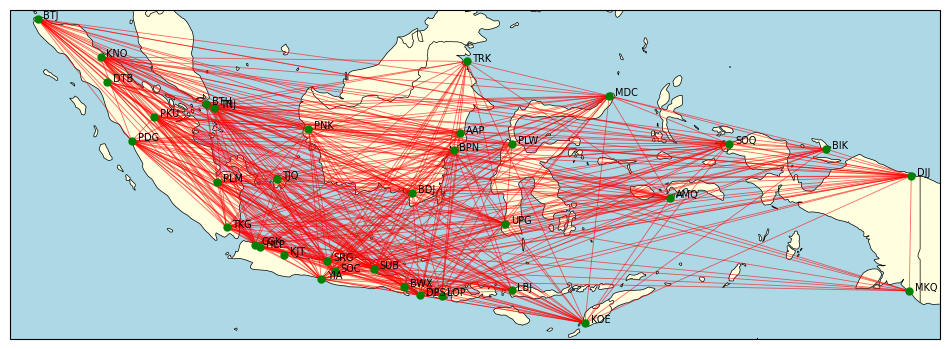

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import airportsdata




# =========================================================
# 2. AMBIL KOORDINAT BANDARA
# =========================================================
airports = airportsdata.load('IATA')

# Tambahkan koordinat manual jika ada yang hilang
airports['BWX'] = {'lat': -8.3102, 'lon': 114.3406}

def get_coords(iata):
    rec = airports.get(iata)
    if rec:
        return rec['lat'], rec['lon']
    return None, None

# Ambil koordinat untuk Bandara1 dan Bandara2
df[['Lat_Origin', 'Lon_Origin']] = df['Bandara1'].apply(lambda x: pd.Series(get_coords(x)))
df[['Lat_Destination', 'Lon_Destination']] = df['Bandara2'].apply(lambda x: pd.Series(get_coords(x)))

# Hapus rute tanpa koordinat lengkap
df = df.dropna(subset=['Lat_Origin','Lon_Origin','Lat_Destination','Lon_Destination'])

# =========================================================
# 3. BANGUN GRAF AGREGAT
# =========================================================
G = nx.Graph()

for _, row in df.iterrows():
    u, v = sorted([row['Bandara1'], row['Bandara2']])
    w = row.get('Weight_norm', 1)
    if G.has_edge(u, v):
        G[u][v]['Weight_norm'] += w
    else:
        G.add_edge(u, v, Weight_norm=w)

# =========================================================
# 4. SET POSISI NODE
# =========================================================
pos = {}
for _, row in df.iterrows():
    if row['Bandara1'] not in pos:
        pos[row['Bandara1']] = (row['Lon_Origin'], row['Lat_Origin'])
    if row['Bandara2'] not in pos:
        pos[row['Bandara2']] = (row['Lon_Destination'], row['Lat_Destination'])

nx.set_node_attributes(G, pos, 'pos')

# =========================================================
# 5. TAMPILKAN PEMETAAN v_i ↔ KODE BANDARA
# =========================================================
np.set_printoptions(threshold=np.inf, linewidth=200)

nodes = list(G.nodes())
node_to_v = {node: f"v{i+1}" for i, node in enumerate(nodes)}
v_to_node = {f"v{i+1}": node for i, node in enumerate(nodes)}

mapping_df = pd.DataFrame({
    "Simpul (v_i)": list(v_to_node.keys()),
    "Bandara": list(v_to_node.values())
})
print("\nTabel Pemetaan Simpul:")
print(mapping_df.to_string(index=False))

# =========================================================
# 6. VISUALISASI PETA INDONESIA (LABEL = v_i)
# =========================================================
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightyellow')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

ax.set_extent([94, 142, -11, 6], crs=ccrs.PlateCarree())

# Gambar rute penerbangan
for u, v, d in G.edges(data=True):
    lon_u, lat_u = G.nodes[u]['pos']
    lon_v, lat_v = G.nodes[v]['pos']
    plt.plot([lon_u, lon_v], [lat_u, lat_v],
             color='red', linewidth=0.6, alpha=0.6,
             transform=ccrs.PlateCarree())

# Gambar node bandara dengan label v_i
for node, (lon, lat) in pos.items():
    plt.plot(lon, lat, marker='o', color='green', markersize=5,
             transform=ccrs.PlateCarree())
    plt.text(lon + 0.3, lat, node_to_v[node], fontsize=7, color='black',
             transform=ccrs.PlateCarree())

plt.show()


In [ ]:
print("Jumlah node :", G.number_of_nodes())
print("Jumlah edge :", G.number_of_edges())

Jumlah node : 35
Jumlah edge : 403


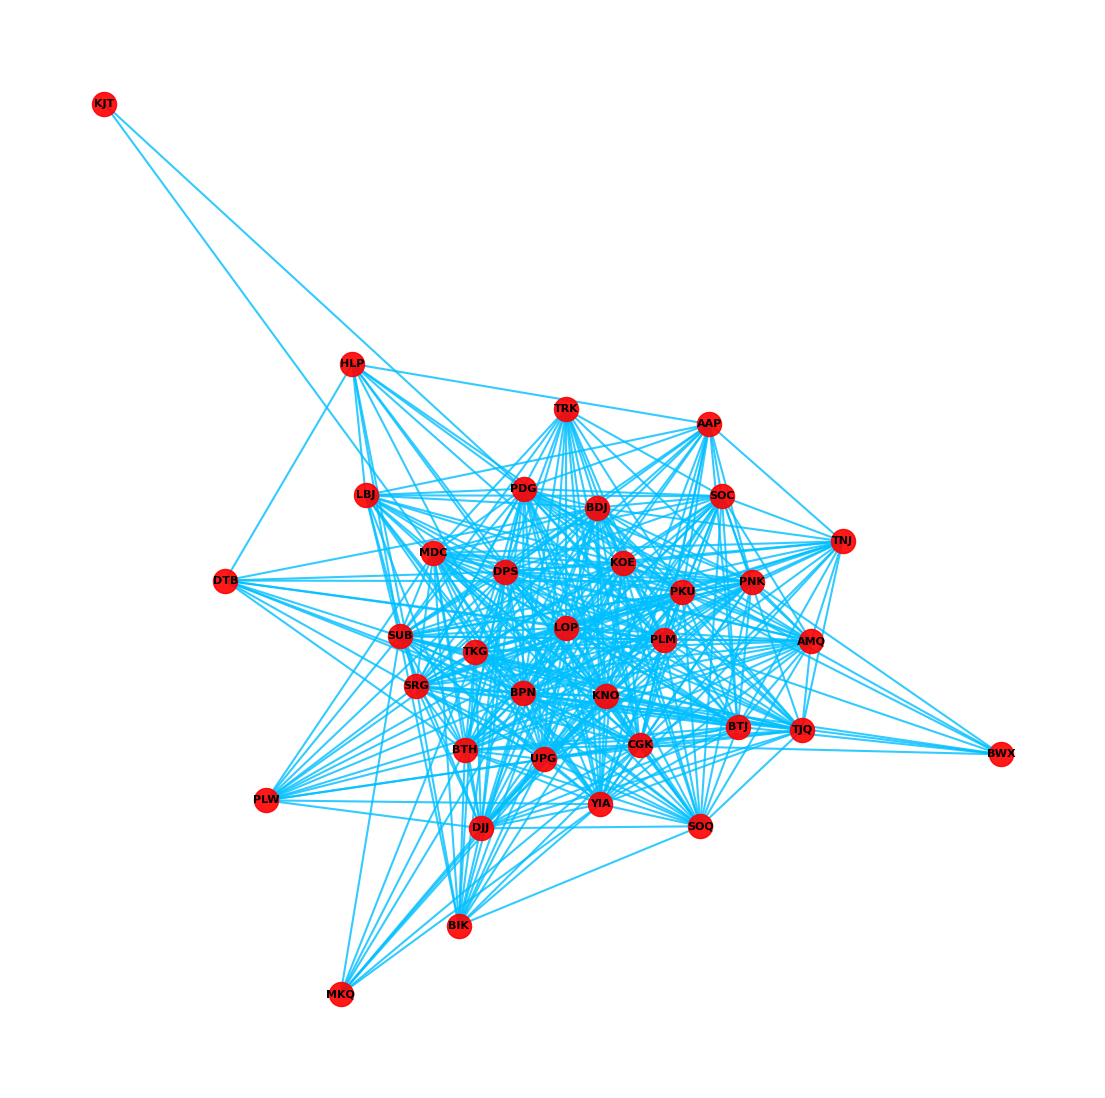

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import airportsdata


# =========================================================
# 2. AMBIL KOORDINAT BANDARA
# =========================================================
airports = airportsdata.load('IATA')
airports['BWX'] = {'lat': -8.3102, 'lon': 114.3406}

def get_coords(iata):
    rec = airports.get(iata)
    if rec:
        return rec['lat'], rec['lon']
    return None, None

df[['Lat_Origin', 'Lon_Origin']] = df['Bandara1'].apply(lambda x: pd.Series(get_coords(x)))
df[['Lat_Destination', 'Lon_Destination']] = df['Bandara2'].apply(lambda x: pd.Series(get_coords(x)))

df = df.dropna(subset=['Lat_Origin','Lon_Origin','Lat_Destination','Lon_Destination'])

# =========================================================
# 3. BANGUN GRAF AGREGAT
# =========================================================
G = nx.Graph()
for _, row in df.iterrows():
    u, v = sorted([row['Bandara1'], row['Bandara2']])
    w = row.get('Weight_norm', 1)
    if G.has_edge(u, v):
        G[u][v]['weight_norm'] += w
    else:
        G.add_edge(u, v, weight=w)

# =========================================================
# 4. SET POSISI NODE
# =========================================================
pos = {}
for _, row in df.iterrows():
    if row['Bandara1'] not in pos:
        pos[row['Bandara1']] = (row['Lon_Origin'], row['Lat_Origin'])
    if row['Bandara2'] not in pos:
        pos[row['Bandara2']] = (row['Lon_Destination'], row['Lat_Destination'])
nx.set_node_attributes(G, pos, 'pos')

# =========================================================
# 5. PEMETAAN v_i ↔ BANDARA
# =========================================================
nodes = list(G.nodes())
node_to_v = {node: f"v{i+1}" for i, node in enumerate(nodes)}
v_to_node = {f"v{i+1}": node for i, node in enumerate(nodes)}

mapping_df = pd.DataFrame({
    "Simpul (v_i)": list(v_to_node.keys()),
    "Bandara": list(v_to_node.values())
})
print("\nTabel Pemetaan Simpul:")
print(mapping_df.to_string(index=False))

# =========================================================
# 6. VISUALISASI PETA INDONESIA (LABEL v_i BOLD, TITIK BOLD)
# =========================================================
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightyellow')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

ax.set_extent([94, 142, -11, 6], crs=ccrs.PlateCarree())

# Gambar rute penerbangan
for u, v, d in G.edges(data=True):
    lon_u, lat_u = G.nodes[u]['pos']
    lon_v, lat_v = G.nodes[v]['pos']
    plt.plot([lon_u, lon_v], [lat_u, lat_v],
             color='red', linewidth=0.8, alpha=0.6,
             transform=ccrs.PlateCarree())

# Gambar node dengan label v_i BOLD dan titik lebih besar
for node, (lon, lat) in pos.items():
    # Titik node
    plt.scatter(lon, lat,
                s=30,                 # ukuran lebih besar
                color='green',
                # border hitam
                zorder=5,
                transform=ccrs.PlateCarree())
    # Label v_i bold
    plt.text(lon + 0.3, lat, node_to_v[node],
             fontsize=8, fontweight='bold', color='black',
             transform=ccrs.PlateCarree())

plt.show()
